<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Modules-required" data-toc-modified-id="Modules-required-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Modules required</a></span></li><li><span><a href="#Data-cleaning" data-toc-modified-id="Data-cleaning-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Data cleaning</a></span></li><li><span><a href="#Objective--Landslide-Prediction" data-toc-modified-id="Objective--Landslide-Prediction-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Objective- Landslide Prediction</a></span></li><li><span><a href="#Modelling" data-toc-modified-id="Modelling-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Modelling</a></span></li><li><span><a href="#Spliting-the-dataset-into-train-and-test" data-toc-modified-id="Spliting-the-dataset-into-train-and-test-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Spliting the dataset into train and test</a></span></li><li><span><a href="#Scaling" data-toc-modified-id="Scaling-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Scaling</a></span></li><li><span><a href="#Model-Building-For-Regression-Analysis" data-toc-modified-id="Model-Building-For-Regression-Analysis-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Model Building For Regression Analysis</a></span><ul class="toc-item"><li><span><a href="#Logistic-Regression" data-toc-modified-id="Logistic-Regression-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>Logistic Regression</a></span></li><li><span><a href="#Decision-Tree" data-toc-modified-id="Decision-Tree-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>Decision Tree</a></span></li><li><span><a href="#Random-Forest" data-toc-modified-id="Random-Forest-7.3"><span class="toc-item-num">7.3&nbsp;&nbsp;</span>Random Forest</a></span></li></ul></li><li><span><a href="#Important-Features" data-toc-modified-id="Important-Features-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Important Features</a></span></li><li><span><a href="#future-task" data-toc-modified-id="future-task-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>future task</a></span></li></ul></div>

# Modules required

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# reading data
df = pd.read_csv('Complete-data.csv')
df.head()

,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
0,0,3,3,2,2,2,1,4,2,2,3,3,2
1,0,1,5,2,3,1,1,4,2,5,5,2,2
2,0,3,4,3,2,2,4,3,2,4,5,2,2
3,0,1,3,3,3,5,1,2,4,3,5,3,3
4,0,5,4,2,1,4,1,2,4,3,3,1,4


In [ ]:
# size of dataset
df.shape

(1212, 13)

In [ ]:
df['Landslide'].unique()

array([0, 1], dtype=int64)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Landslide      1212 non-null   int64
 1   Aspect         1212 non-null   int64
 2   Curvature      1212 non-null   int64
 3   Earthquake     1212 non-null   int64
 4   Elevation      1212 non-null   int64
 5   Flow           1212 non-null   int64
 6   Lithology      1212 non-null   int64
 7   NDVI           1212 non-null   int64
 8   NDWI           1212 non-null   int64
 9   Plan           1212 non-null   int64
 10  Precipitation  1212 non-null   int64
 11  Profile        1212 non-null   int64
 12  Slope          1212 non-null   int64
dtypes: int64(13)
memory usage: 123.2 KB


In [ ]:
#Check for missing values
'''The easiest way to check for missing values in a Pandas dataframe is via the isna() function. 
The isna() function returns a boolean (True or False) value if the Pandas column value is missing, 
so if you run df.isna() you’ll get back a dataframe showing you a load of boolean values.'''

df.isna().head()

,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
'''That’s not usually very useful, 
so instead we’ll calculate the sum() of missing values by running df.isna().sum(). 
This returns the columns in our Pandas dataframe along with the number of missing 
values detected in each one, so 0 means there are no missing values, and 1 means there is 
a single missing value.'''

'That’s not usually very useful, \nso instead we’ll calculate the sum() of missing values by running df.isna().sum(). \nThis returns the columns in our Pandas dataframe along with the number of missing \nvalues detected in each one, so 0 means there are no missing values, and 1 means there is \na single missing value.'

In [ ]:
df.isna().sum()

Landslide        0
Aspect           0
Curvature        0
Earthquake       0
Elevation        0
Flow             0
Lithology        0
NDVI             0
NDWI             0
Plan             0
Precipitation    0
Profile          0
Slope            0
dtype: int64

In [ ]:
df.isnull().sum()

Landslide        0
Aspect           0
Curvature        0
Earthquake       0
Elevation        0
Flow             0
Lithology        0
NDVI             0
NDWI             0
Plan             0
Precipitation    0
Profile          0
Slope            0
dtype: int64

In [ ]:
df.describe()

,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
count,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000
mean,0.500000,2.962046,2.977723,2.102310,2.436469,2.338284,1.948845,3.042904,2.773927,3.059406,3.813531,3.262376,2.811881
std,0.500206,1.147378,1.099658,0.669812,1.242686,1.112686,1.424345,1.239246,1.299830,1.057287,1.347799,1.039502,1.194229
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,3.000000,3.000000,2.000000
50%,0.500000,3.000000,3.000000,2.000000,2.000000,2.000000,1.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000
75%,1.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000
max,1.000000,5.000000,5.000000,3.000000,5.000000,5.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# Data cleaning
'''NaN (Not a Number) is a numeric data type that means an undefined value or value that cannot be 
represented, especially results of floating-point calculations.

Change MISSING notation data with NaN Value.
'''

In [ ]:
df = df.replace('MISSING', np.nan)
df.isnull().sum()

Landslide        0
Aspect           0
Curvature        0
Earthquake       0
Elevation        0
Flow             0
Lithology        0
NDVI             0
NDWI             0
Plan             0
Precipitation    0
Profile          0
Slope            0
dtype: int64

In [ ]:
print('size of dataset:', np.size(df))
print(df.shape)

size of dataset: 15756
(1212, 13)


In [ ]:
#Delete A row that contain NaN in the column or variable of the dataset
df1 = df.replace('MISSING', np.nan).dropna().reset_index(drop=True)
print('New size:', np.size(df1))
df1.isnull().sum()

New size: 15756


Landslide        0
Aspect           0
Curvature        0
Earthquake       0
Elevation        0
Flow             0
Lithology        0
NDVI             0
NDWI             0
Plan             0
Precipitation    0
Profile          0
Slope            0
dtype: int64

# Objective- Landslide Prediction

As, our goal is to make a model of Machine Learning for Lanslide Prediction. So first we should try to identify the relationship that exists among the features or columns to get some insight for further analysis. 

Here we use the Pearson Correlation method which tell us about the linear relationship between two features, and the value varies between -1 and 1, where:

(-1) means Maximum negative linear correlation.
(0) means No linear correlation.
(1) means Maximum Positive linear correlation. 



In [ ]:
df1

,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
0,0,3,3,2,2,2,1,4,2,2,3,3,2
1,0,1,5,2,3,1,1,4,2,5,5,2,2
2,0,3,4,3,2,2,4,3,2,4,5,2,2
3,0,1,3,3,3,5,1,2,4,3,5,3,3
4,0,5,4,2,1,4,1,2,4,3,3,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207,1,4,2,1,4,2,5,1,5,3,2,4,2
1208,1,4,5,1,5,3,5,1,5,5,2,1,5
1209,1,3,4,1,5,2,5,2,3,3,2,2,5
1210,1,2,2,1,3,1,1,5,1,1,1,3,3


In [ ]:
df1.corr()

,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
Landslide,1.000000,-0.008633,-0.173393,0.187313,-0.168049,-0.261124,-0.120538,0.111900,-0.194317,-0.103052,0.280490,0.169928,0.123029
Aspect,-0.008633,1.000000,-0.024232,0.014727,0.017998,0.024295,0.025086,-0.158561,0.168099,-0.043066,-0.010454,-0.015876,0.048420
Curvature,-0.173393,-0.024232,1.000000,-0.049595,0.193843,0.025736,0.058319,0.094625,-0.089028,0.815075,-0.104207,-0.806851,0.143316
Earthquake,0.187313,0.014727,-0.049595,1.000000,0.071308,0.003382,0.095507,-0.134619,0.118588,-0.022582,0.825169,0.049177,0.055050
Elevation,-0.168049,0.017998,0.193843,0.071308,1.000000,0.026903,0.429702,-0.217003,0.187921,0.104691,-0.003628,-0.228721,0.333029
Flow,-0.261124,0.024295,0.025736,0.003382,0.026903,1.000000,-0.033881,-0.393805,0.462291,0.041163,0.002451,-0.011119,-0.078842
Lithology,-0.120538,0.025086,0.058319,0.095507,0.429702,-0.033881,1.000000,-0.129279,0.119080,0.008051,0.005351,-0.048930,0.169103
NDVI,0.111900,-0.158561,0.094625,-0.134619,-0.217003,-0.393805,-0.129279,1.000000,-0.931590,0.102043,-0.096063,-0.042720,0.041726
NDWI,-0.194317,0.168099,-0.089028,0.118588,0.187921,0.462291,0.119080,-0.931590,1.000000,-0.097774,0.078201,0.040269,-0.098171
Plan,-0.103052,-0.043066,0.815075,-0.022582,0.104691,0.041163,0.008051,0.102043,-0.097774,1.000000,-0.072768,-0.487539,0.055292


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Landslide      1212 non-null   int64
 1   Aspect         1212 non-null   int64
 2   Curvature      1212 non-null   int64
 3   Earthquake     1212 non-null   int64
 4   Elevation      1212 non-null   int64
 5   Flow           1212 non-null   int64
 6   Lithology      1212 non-null   int64
 7   NDVI           1212 non-null   int64
 8   NDWI           1212 non-null   int64
 9   Plan           1212 non-null   int64
 10  Precipitation  1212 non-null   int64
 11  Profile        1212 non-null   int64
 12  Slope          1212 non-null   int64
dtypes: int64(13)
memory usage: 123.2 KB


In [ ]:
df1.corr()

,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
Landslide,1.000000,-0.008633,-0.173393,0.187313,-0.168049,-0.261124,-0.120538,0.111900,-0.194317,-0.103052,0.280490,0.169928,0.123029
Aspect,-0.008633,1.000000,-0.024232,0.014727,0.017998,0.024295,0.025086,-0.158561,0.168099,-0.043066,-0.010454,-0.015876,0.048420
Curvature,-0.173393,-0.024232,1.000000,-0.049595,0.193843,0.025736,0.058319,0.094625,-0.089028,0.815075,-0.104207,-0.806851,0.143316
Earthquake,0.187313,0.014727,-0.049595,1.000000,0.071308,0.003382,0.095507,-0.134619,0.118588,-0.022582,0.825169,0.049177,0.055050
Elevation,-0.168049,0.017998,0.193843,0.071308,1.000000,0.026903,0.429702,-0.217003,0.187921,0.104691,-0.003628,-0.228721,0.333029
Flow,-0.261124,0.024295,0.025736,0.003382,0.026903,1.000000,-0.033881,-0.393805,0.462291,0.041163,0.002451,-0.011119,-0.078842
Lithology,-0.120538,0.025086,0.058319,0.095507,0.429702,-0.033881,1.000000,-0.129279,0.119080,0.008051,0.005351,-0.048930,0.169103
NDVI,0.111900,-0.158561,0.094625,-0.134619,-0.217003,-0.393805,-0.129279,1.000000,-0.931590,0.102043,-0.096063,-0.042720,0.041726
NDWI,-0.194317,0.168099,-0.089028,0.118588,0.187921,0.462291,0.119080,-0.931590,1.000000,-0.097774,0.078201,0.040269,-0.098171
Plan,-0.103052,-0.043066,0.815075,-0.022582,0.104691,0.041163,0.008051,0.102043,-0.097774,1.000000,-0.072768,-0.487539,0.055292


In [ ]:
df1.columns

Index(['Landslide', 'Aspect', 'Curvature', 'Earthquake', 'Elevation', 'Flow',
       'Lithology', 'NDVI', 'NDWI', 'Plan', 'Precipitation', 'Profile',
       'Slope'],
      dtype='object')

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Landslide      1212 non-null   int64
 1   Aspect         1212 non-null   int64
 2   Curvature      1212 non-null   int64
 3   Earthquake     1212 non-null   int64
 4   Elevation      1212 non-null   int64
 5   Flow           1212 non-null   int64
 6   Lithology      1212 non-null   int64
 7   NDVI           1212 non-null   int64
 8   NDWI           1212 non-null   int64
 9   Plan           1212 non-null   int64
 10  Precipitation  1212 non-null   int64
 11  Profile        1212 non-null   int64
 12  Slope          1212 non-null   int64
dtypes: int64(13)
memory usage: 123.2 KB


In [ ]:
df1.head()

,Landslide,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
0,0,3,3,2,2,2,1,4,2,2,3,3,2
1,0,1,5,2,3,1,1,4,2,5,5,2,2
2,0,3,4,3,2,2,4,3,2,4,5,2,2
3,0,1,3,3,3,5,1,2,4,3,5,3,3
4,0,5,4,2,1,4,1,2,4,3,3,1,4


In [ ]:
landslide_count = df['Landslide'].value_counts()
landslide_count

0    606
1    606
Name: Landslide, dtype: int64

In [ ]:
landslide_count.index

Int64Index([0, 1], dtype='int64')

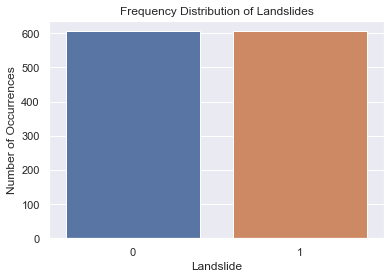

In [ ]:
sns.set(style="darkgrid")
sns.countplot(x ='Landslide', data = df)
plt.title('Frequency Distribution of Landslides')
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Landslide', fontsize=12)
plt.show()

<AxesSubplot:>

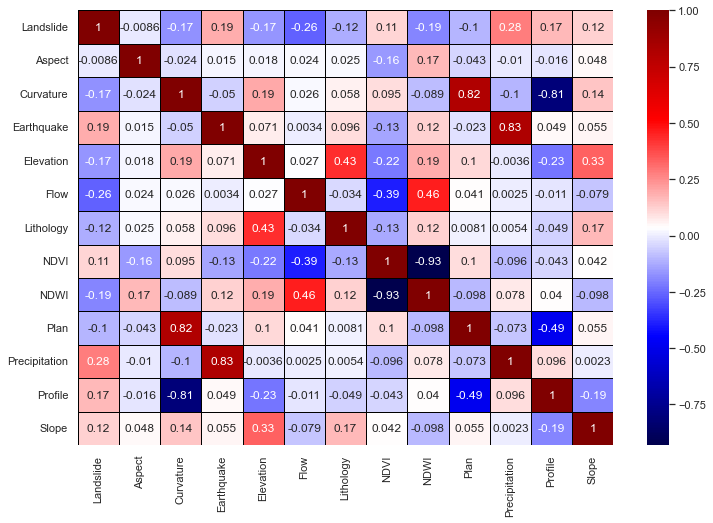

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(df1.corr(), annot=True, linecolor='black', linewidths=1, cmap='seismic')

<AxesSubplot:>

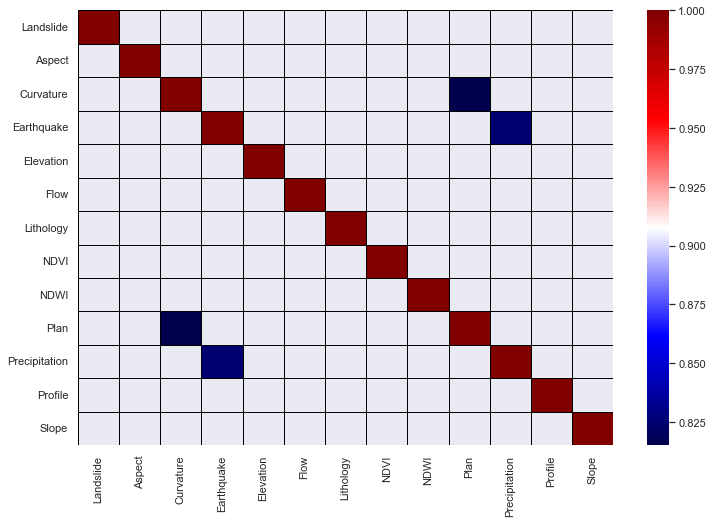

In [ ]:
#Specific check to the all Correlation values above 0.8
#Data Frame Preparation
corr = df1.corr()
cond_corr = corr[corr>0.8]

#Plot Heat Map
plt.figure(figsize=(12,8))
sns.heatmap(cond_corr, linecolor='black', linewidths=1, cmap='seismic')

In [ ]:
#List All Correlation values above 0.8
cond_corr_sort = cond_corr
cond_corr_sort.replace(1, np.nan, inplace=True)
df_high_corr = cond_corr_sort.abs().unstack().drop_duplicates(keep='first').sort_values(ascending=False).to_frame(name='Correlation Value')
df_high_corr

,,Correlation Value
Earthquake,Precipitation,0.825169
Curvature,Plan,0.815075
Landslide,Landslide,NaN


# Modelling

In [ ]:
df1.columns

Index(['Landslide', 'Aspect', 'Curvature', 'Earthquake', 'Elevation', 'Flow',
       'Lithology', 'NDVI', 'NDWI', 'Plan', 'Precipitation', 'Profile',
       'Slope'],
      dtype='object')

In [ ]:
y = df1['Landslide']
X = df.loc[:, df.columns != 'Landslide']

In [ ]:
X

,Aspect,Curvature,Earthquake,Elevation,Flow,Lithology,NDVI,NDWI,Plan,Precipitation,Profile,Slope
0,3,3,2,2,2,1,4,2,2,3,3,2
1,1,5,2,3,1,1,4,2,5,5,2,2
2,3,4,3,2,2,4,3,2,4,5,2,2
3,1,3,3,3,5,1,2,4,3,5,3,3
4,5,4,2,1,4,1,2,4,3,3,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1207,4,2,1,4,2,5,1,5,3,2,4,2
1208,4,5,1,5,3,5,1,5,5,2,1,5
1209,3,4,1,5,2,5,2,3,3,2,2,5
1210,2,2,1,3,1,1,5,1,1,1,3,3


In [ ]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1207    1
1208    1
1209    1
1210    1
1211    1
Name: Landslide, Length: 1212, dtype: int64

# Spliting the dataset into train and test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=0)
X_train.shape, X_test.shape

NameError: name 'train_test_split' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#from statsmodels.stats.outliers_influence import variance_inflation_factor
#import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error,mean_absolute_percentage_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import bz2,pickle

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
#from xgboost import XGBClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=0)
X_train.shape, X_test.shape

((909, 12), (303, 12))

# Scaling

In [ ]:
def scaler_standard(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled

In [ ]:
X_train_scaled, X_test_scaled = scaler_standard(X_train, X_test)

Text(0.5, 1.0, 'X_train After Scaling')

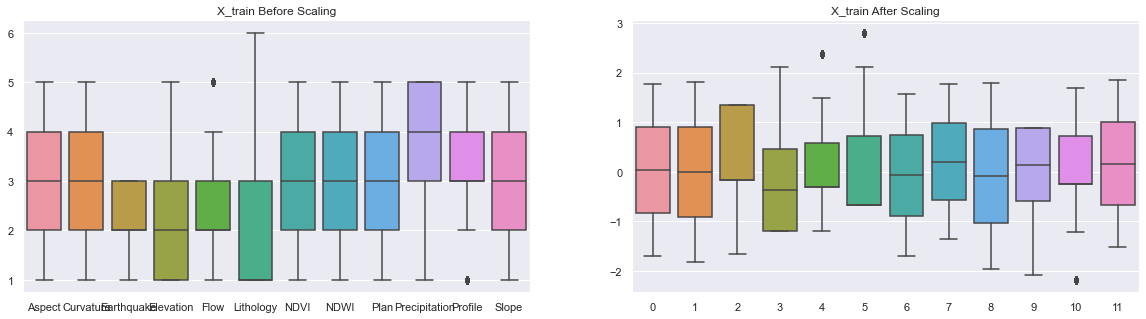

In [ ]:
plt.subplots(figsize=(20, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

# Model Building For Regression Analysis

## Logistic Regression

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)  # training the model

print('Accuracy of Logistic regression classifier on training set: {:.6f}'
     .format(log_reg.score(X_train_scaled, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.6f}'
     .format(log_reg.score(X_test_scaled, y_test)))

Accuracy of Logistic regression classifier on training set: 0.759076
Accuracy of Logistic regression classifier on test set: 0.729373


In [ ]:
# prediction
Logistic_Regression_Prediction = log_reg.predict(X_test_scaled)
predicted_df = pd.DataFrame({'Actual': y_test, 'Predicted ': Logistic_Regression_Prediction})    
predicted_df.head(10)

,Actual,Predicted
198,0,1
1009,1,1
55,0,0
743,1,1
907,1,1
1062,1,1
692,1,1
431,0,0
1118,1,0
487,0,0


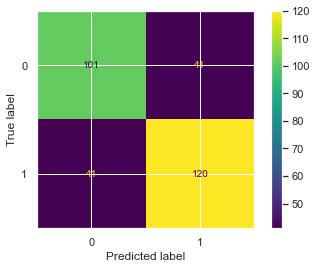

In [ ]:
# confusion matrix
LR_CM = ConfusionMatrixDisplay.from_estimator(log_reg, X_test_scaled, y_test)
LR_CM
plt.show()

## Decision Tree

In [ ]:
DT_clf = DecisionTreeClassifier()
DT_clf .fit(X_train_scaled, y_train)
print('Accuracy of Decision Tree Classifier on training set: {:.4f}'
     .format(DT_clf .score(X_train_scaled, y_train)))
print('Accuracy of Decision Tree Classifier on test set: {:.4f}'
     .format(DT_clf .score(X_test_scaled, y_test)))

Accuracy of Decision Tree Classifier on training set: 0.9967
Accuracy of Decision Tree Classifier on test set: 0.7063


In [ ]:
DT_Prediction = DT_clf.predict(X_test_scaled)
DT_predicted_df = pd.DataFrame({'Actual': y_test, 'Predicted ': DT_Prediction})    
DT_predicted_df.head(10)

,Actual,Predicted
198,0,1
1009,1,1
55,0,1
743,1,1
907,1,1
1062,1,1
692,1,1
431,0,1
1118,1,1
487,0,0


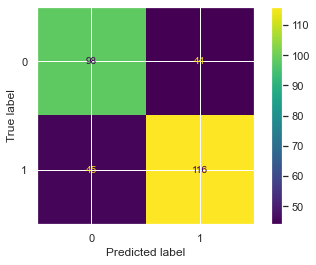

In [ ]:
DT_Confusion_Matrix = ConfusionMatrixDisplay.from_estimator(DT_clf , X_test_scaled, y_test)
DT_Confusion_Matrix
plt.show()

## Random Forest 

In [ ]:
RF_clf = RandomForestClassifier()
RF_clf.fit(X_train_scaled, y_train)
print('Accuracy of Random Forest classifier on training set: {:.4f}'
     .format(RF_clf .score(X_train_scaled, y_train)))
print('Accuracy of Random Forest classifier on test set: {:.4f}'
     .format(RF_clf .score(X_test_scaled, y_test)))

Accuracy of Random Forest classifier on training set: 0.9967
Accuracy of Random Forest classifier on test set: 0.7591


In [ ]:
RF_Prediction = RF_clf.predict(X_test_scaled)
RF_predicted_df = pd.DataFrame({'Actual': y_test, 'Predicted ': RF_Prediction})    
RF_predicted_df.head(10)

,Actual,Predicted
198,0,1
1009,1,1
55,0,0
743,1,1
907,1,1
1062,1,1
692,1,1
431,0,1
1118,1,1
487,0,0


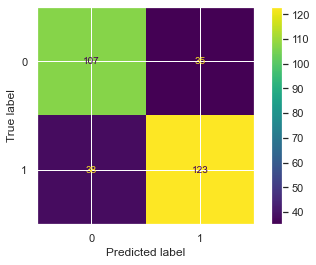

In [ ]:
RF_Confusion_Matrix = ConfusionMatrixDisplay.from_estimator(RF_clf , X_test_scaled, y_test)
RF_Confusion_Matrix
plt.show()

# Important Features

In [ ]:
feature_importances = RF_clf.feature_importances_
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
0,Aspect,0.108716
4,Flow,0.107432
9,Precipitation,0.103307
3,Elevation,0.101261
11,Slope,0.097534
10,Profile,0.080009
5,Lithology,0.079808
7,NDWI,0.068346
1,Curvature,0.065461
8,Plan,0.063687


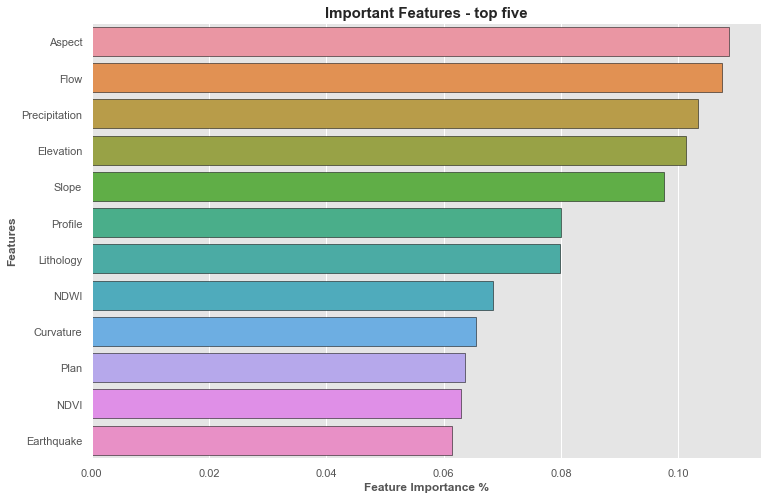

In [ ]:
plt.style.use('ggplot')
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=importance_df, x='importance', y='feature',ec = 'black')
ax.set_title('Important Features - top five', weight='bold',fontsize = 15)
ax.set_xlabel('Feature Importance %',weight='bold')
ax.set_ylabel('Features',weight='bold')
plt.show()

# future task